## 1) Dataset Loading and Initial Inspection
This cell imports the necessary libraries, loads the cleaned dataset, and displays the shape and first few rows to confirm that the data is correctly structured.

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
PROJECT_ROOT = os.path.abspath("..")  
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")

CLEAN_PATH = os.path.join(PROCESSED_DIR, "sentiment_mental_health_clean.csv")

# Load data
df = pd.read_csv(CLEAN_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (50962, 2)
Columns: ['statement', 'status']


,statement,status
0,oh my gosh,Anxiety
1,trouble sleeping confused mind restless heart ...,Anxiety
2,all wrong back off dear forward doubt stay in ...,Anxiety
3,i ve shifted my focus to something else but i ...,Anxiety
4,i m restless and restless it s been a month no...,Anxiety


In [14]:
TEXT_COL = "statement"   
LABEL_COL = "status" 

In [54]:
import os

# Paths
PROJECT_ROOT = os.path.abspath("..")  
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")
EDA_DIR = os.path.join(REPORTS_DIR, "EDA")

os.makedirs(EDA_DIR, exist_ok=True)
print("EDA reports directory:", EDA_DIR)

EDA reports directory: /Users/solaris003/Repository/Fall'25/S-NLP/MindScope-AI/reports/EDA


In [55]:
import matplotlib.pyplot as plt

def save_eda_fig(filename: str, dpi: int = 300):
    """
    Save the current matplotlib figure into reports/EDA with the given filename.
    Example: save_eda_fig("label_distribution.png")
    """
    filepath = os.path.join(EDA_DIR, filename)
    plt.savefig(filepath, dpi=dpi, bbox_inches="tight")
    print(f"Figure saved to: {filepath}")

In [65]:
import matplotlib.pyplot as plt

def save_table_as_image(df, filename):
    # 1. Move index into a real column called "status"
    df_to_plot = df.reset_index().rename(columns={"index": "status"})
    n_rows, n_cols = df_to_plot.shape

    # 2. Create figure
    fig, ax = plt.subplots(figsize=(3 + 2 * n_cols, 0.6 + 0.4 * n_rows))
    ax.axis("off")

    # 3. Build table
    table = ax.table(
        cellText=df_to_plot.values,
        colLabels=df_to_plot.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.3)

    # 4. Make header row and first column bold
    for (row, col), cell in table.get_celld().items():
        # row 0 is header, col 0 is 'status' and its values
        if row == 0 or col == 0:
            cell.get_text().set_weight("bold")

    # 5. Save to reports/EDA
    filepath = os.path.join(EDA_DIR, filename)
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved table image to: {filepath}")


## 2) Label Distribution of Mental Health Categories  
This pie chart visualizes the proportion of each mental health label in the dataset, highlighting class imbalance across categories such as Normal, Depression, Suicidal, Anxiety, Bipolar, Stress, and Personality Disorder.


Figure saved to: /Users/solaris003/Repository/Fall'25/S-NLP/MindScope-AI/reports/EDA/label_distribution.png


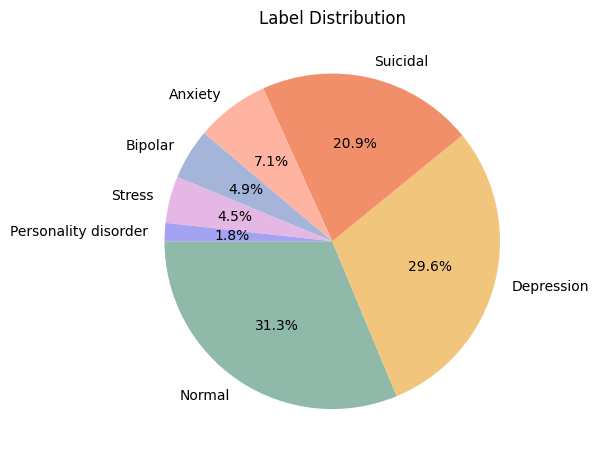

In [59]:
import matplotlib.pyplot as plt

label_counts = df[LABEL_COL].value_counts()
label_percent = (label_counts / len(df) * 100).round(2)

palette = {
    "Normal":               "#8FB9A8", 
    "Depression":           "#F2C57C",  
    "Suicidal":             "#F28F6B", 
    "Anxiety":              "#FFB4A2",  
    "Bipolar":              "#A5B5D9", 
    "Stress":               "#E4B7E5",  
    "Personality disorder": "#A4A3F1",  
}

colors = [palette[label] for label in label_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct="%1.1f%%",
    startangle=180,
    colors=colors[: len(label_counts)]
)
plt.title("Label Distribution")
plt.tight_layout()
save_eda_fig("label_distribution.png") 
plt.show()

This table presents the frequency and proportion of each mental health category, providing a clear overview of class distribution and highlighting the imbalance across labels.

In [63]:
label_summary = pd.DataFrame({
    "count": label_counts,
    "percentage": label_percent
}).sort_values("count", ascending=False)

label_summary


,count,percentage
status,,
Normal,15938,31.27
Depression,15090,29.61
Suicidal,10634,20.87
Anxiety,3614,7.09
Bipolar,2501,4.91
Stress,2291,4.50
Personality disorder,894,1.75


In [66]:
save_table_as_image(label_summary, "label_summary.png")

Saved table image to: /Users/solaris003/Repository/Fall'25/S-NLP/MindScope-AI/reports/EDA/label_summary.png


## 3) Text Length Statistics and Distribution by Label  
This section computes descriptive statistics for token counts across labels and visualizes the distribution using a boxplot, highlighting differences in post lengths among the mental health categories.


In [48]:
# Define the desired label order
label_order = [
    "Normal",
    "Depression",
    "Suicidal",
    "Anxiety",
    "Bipolar",
    "Stress",
    "Personality disorder",
]

# Convert label column to ordered categorical
df[LABEL_COL] = pd.Categorical(
    df[LABEL_COL],
    categories=label_order,
    ordered=True
)


In [49]:
df["num_tokens"] = df[TEXT_COL].str.split().str.len()

length_by_label = (
    df.groupby(LABEL_COL, observed=False)["num_tokens"]
      .agg(["mean", "median", "min", "max", "count"])
      .round(2)
)

display(length_by_label)

,mean,median,min,max,count
status,,,,,
Normal,17.95,10.0,1,264,15938
Depression,169.74,114.0,1,4239,15090
Suicidal,147.70,93.0,1,6300,10634
Anxiety,148.92,107.0,1,1672,3614
Bipolar,185.49,136.0,4,4879,2501
Stress,115.29,89.0,1,1656,2291
Personality disorder,184.97,137.0,4,5588,894


In [67]:
save_table_as_image(length_by_label, "length_by_label_stats.png")

Saved table image to: /Users/solaris003/Repository/Fall'25/S-NLP/MindScope-AI/reports/EDA/length_by_label_stats.png


Figure saved to: /Users/solaris003/Repository/Fall'25/S-NLP/MindScope-AI/reports/EDA/text_length_boxplot.png


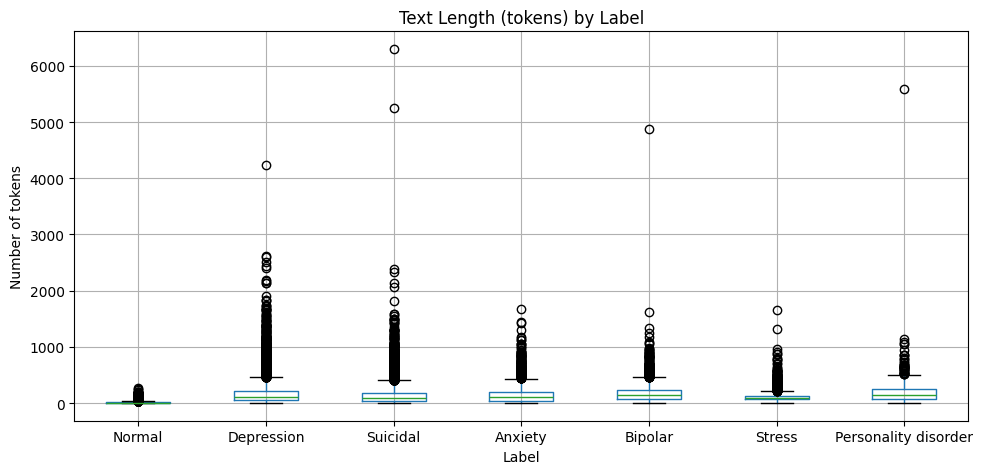

In [68]:
# Boxplot of length by label
fig, ax = plt.subplots(figsize=(10, 5))   

df.boxplot(column="num_tokens", by=LABEL_COL, ax=ax)

ax.set_title("Text Length (tokens) by Label")
ax.set_xlabel("Label")
ax.set_ylabel("Number of tokens")
fig.suptitle("")          
fig.tight_layout()
save_eda_fig("text_length_boxplot.png")
plt.show()


## 4) Emotion Tag Frequency Across the Dataset  
This plot shows how often each emotion tag appears in the cleaned texts, highlighting which emotional expressions (e.g., sad, happy, anxious) are most commonly detected in user posts.


Emotion tag counts:
 sad_emo             530
happy_emo           461
anxious_emo         183
laugh_emo           122
love_support_emo     63
depressed_emo        44
angry_emo            21
confused_emo         17
shocked_emo          15
gratitude_emo         9
tired_emo             2
dtype: int64
Figure saved to: /Users/solaris003/Repository/Fall'25/S-NLP/MindScope-AI/reports/EDA/emotion_tag_frequency.png


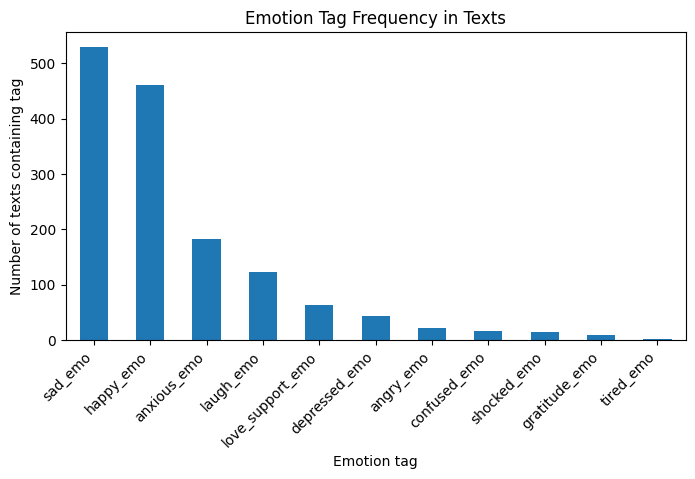

In [69]:
# Define the emotion tags we used in preprocessing
EMO_TAGS = [
    "happy_emo",
    "laugh_emo",
    "love_support_emo",
    "sad_emo",
    "depressed_emo",
    "anxious_emo",
    "angry_emo",
    "confused_emo",
    "shocked_emo",
    "tired_emo",
    "gratitude_emo",
]

for tag in EMO_TAGS:
    df[f"has_{tag}"] = df[TEXT_COL].str.contains(rf"\b{tag}\b", regex=True)

# Count how many rows contain each tag
emo_counts = {tag: df[f"has_{tag}"].sum() for tag in EMO_TAGS}
emo_counts_series = pd.Series(emo_counts).sort_values(ascending=False)

print("Emotion tag counts:\n", emo_counts_series)

# Bar plot of emotion tag frequency
plt.figure(figsize=(8, 4))
emo_counts_series.plot(kind="bar")
plt.title("Emotion Tag Frequency in Texts")
plt.xlabel("Emotion tag")
plt.ylabel("Number of texts containing tag")
plt.xticks(rotation=45, ha="right")
plt.tight_layout
save_eda_fig("emotion_tag_frequency.png")
plt.show()


## 5) Emotion Tag Distribution Across Mental Health Labels  
This table summarizes how frequently each emotion tag appears within each mental health category, providing insight into the emotional patterns associated with different conditions.


In [29]:
# Create has_* columns if not already created
for tag in EMO_TAGS:
    col = f"has_{tag}"
    if col not in df.columns:
        df[col] = df[TEXT_COL].str.contains(rf"\b{tag}\b", regex=True)

In [30]:
rows = []

for label, group in df.groupby(LABEL_COL, observed=False):
    total = len(group)
    row = {"label": label, "total": total}
    for tag in EMO_TAGS:
        col = f"has_{tag}"
        count_with = group[col].sum()
        row[f"{tag}_count"] = count_with
    rows.append(row)

label_order = [
    "Normal",
    "Depression",
    "Suicidal",
    "Anxiety",
    "Bipolar",
    "Stress",
    "Personality disorder",
]

emo_stats_by_label = (
    pd.DataFrame(rows)
      .set_index("label")
      .reindex(label_order)      
)

display(emo_stats_by_label)


,total,happy_emo_count,laugh_emo_count,love_support_emo_count,sad_emo_count,depressed_emo_count,anxious_emo_count,angry_emo_count,confused_emo_count,shocked_emo_count,tired_emo_count,gratitude_emo_count
label,,,,,,,,,,,,
Normal,15938,124,17,13,107,0,7,0,0,1,0,0
Depression,15090,104,32,6,113,4,59,3,4,6,1,1
Suicidal,10634,74,17,0,65,0,40,0,0,0,0,0
Anxiety,3614,68,32,14,155,22,31,8,5,2,1,3
Bipolar,2501,41,9,13,38,5,23,3,4,3,0,2
Stress,2291,23,5,3,21,4,12,0,2,2,0,2
Personality disorder,894,27,10,14,31,9,11,7,2,1,0,1


In [70]:
save_table_as_image(emo_stats_by_label, "emotion_tags_by_label.png")

Saved table image to: /Users/solaris003/Repository/Fall'25/S-NLP/MindScope-AI/reports/EDA/emotion_tags_by_label.png


## 6) Top Content Words per Mental Health Label  
This section extracts meaningful, non-stopword tokens from each post and identifies the most frequent content words within each mental health category to reveal key themes discussed by different groups.


In [74]:
!pip install xlsxwriter

In [44]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Start from sklearn stopwords
STOPWORDS = set(ENGLISH_STOP_WORDS)

# Extra high-frequency but low-information words to drop in EDA
COMMON_BORING = {
    "im", "ive", "dont", "didnt", "cant", "wont", "id", "ill",
    "u", "ur", "youre", "theyre", "wasnt", "isnt", "arent",
    "not", "just", "like", "want", "don", "really",
    "know","did", "didn", "come", "got", "let", 
    "going","make", "went", "having", "need","getting","doesn"
}

STOPWORDS |= COMMON_BORING


In [45]:
import collections

def tokenize_content_words(text: str):
    tokens = text.split()
    # 1. drop emotion tags
    tokens = [t for t in tokens if not t.endswith("_emo")]
    # 2. drop stopwords
    tokens = [t for t in tokens if t not in STOPWORDS]
    # 3. drop very short / numeric tokens
    tokens = [t for t in tokens if len(t) > 2 and not t.isdigit()]
    return tokens


In [76]:
TOP_N = 50  # how many top words per label

label_top_words = {}

for label, group in df.groupby(LABEL_COL, observed=False):
    counter = collections.Counter()
    for text in group[TEXT_COL]:
        counter.update(tokenize_content_words(text))
    label_top_words[label] = counter.most_common(TOP_N)

# Show as tables in your desired order
for label in [
    "Normal", "Depression", "Suicidal",
    "Anxiety", "Bipolar", "Stress", "Personality disorder"
]:
    top_words = label_top_words.get(label, [])
    print(f"\n=== Top {TOP_N} content words for label: {label} ===")
    display(pd.DataFrame(top_words, columns=["word", "count"]))



=== Top 50 content words for label: Normal ===


,word,count
0,time,803
1,good,662
2,people,643
3,day,624
4,work,586
5,think,505
6,today,470
7,feel,442
8,love,410
9,help,375



=== Top 50 content words for label: Depression ===


,word,count
0,feel,16233
1,life,11106
2,time,8306
3,people,7800
4,depression,6399
5,day,5654
6,think,5494
7,help,4782
8,things,4360
9,anymore,4166



=== Top 50 content words for label: Suicidal ===


...

,word,count
0,feel,2170
1,bipolar,1710
2,time,1392
3,life,990
4,people,893
5,meds,860
6,think,836
7,years,829
8,work,813
9,things,804



=== Top 50 content words for label: Stress ===


,word,count
0,feel,1151
1,stress,1125
2,time,890
3,work,681
4,help,592
5,life,567
6,anxiety,563
7,day,501
8,things,485
9,job,443



=== Top 50 content words for label: Personality disorder ===


,word,count
0,people,1019
1,feel,889
2,avpd,504
3,life,483
4,think,478
5,time,441
6,friends,342
7,things,331
8,social,266
9,way,266


In [77]:
import pandas as pd
import os

# Where to save the Excel file
excel_path = os.path.join(EDA_DIR, "top50_words_by_label.xlsx")

label_order = [
    "Normal",
    "Depression",
    "Suicidal",
    "Anxiety",
    "Bipolar",
    "Stress",
    "Personality disorder",
]

with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
    for label in label_order:
        top_words = label_top_words.get(label, [])
        df_tw = pd.DataFrame(top_words, columns=["word", "count"])
        df_tw.to_excel(writer, sheet_name=label, index=False)

print("Saved Excel file to:", excel_path)


Saved Excel file to: /Users/solaris003/Repository/Fall'25/S-NLP/MindScope-AI/reports/EDA/top50_words_by_label.xlsx


## 7) Word Clouds for Selected Mental Health Labels  
This section generates word clouds for Depression, Suicidal, and Normal categories, visually highlighting the most prominent terms used within each group after removing stopwords and emotion tags.


In [67]:
# Run once in a notebook cell
!pip install wordcloud


In [52]:
import collections

def tokenize_no_emotags(text):
    tokens = text.split()
    # exclude tokens that are emotion tags (end with "_emo")
    return [t for t in tokens if not t.endswith("_emo")]

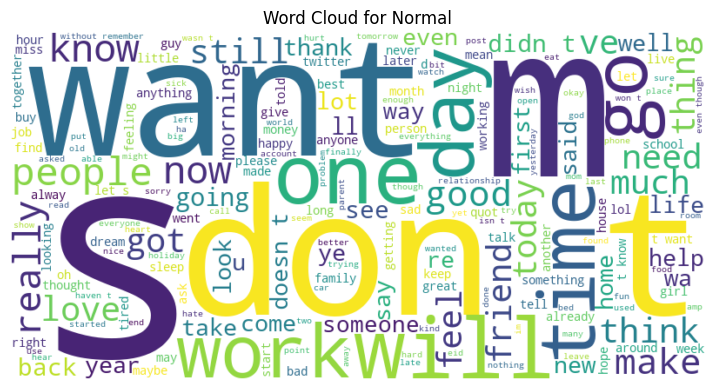

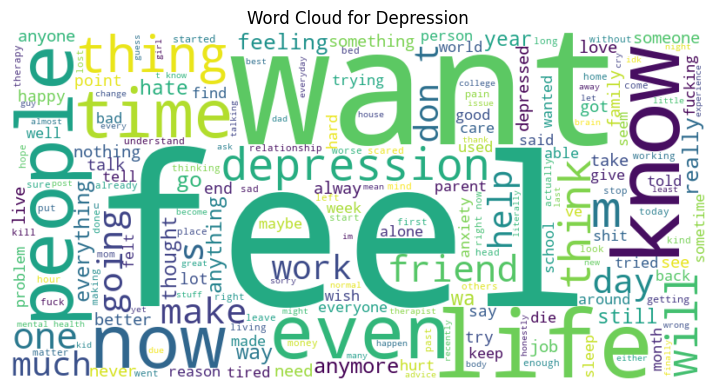

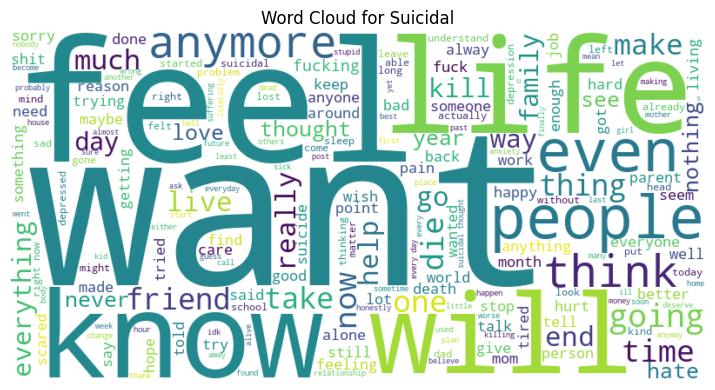

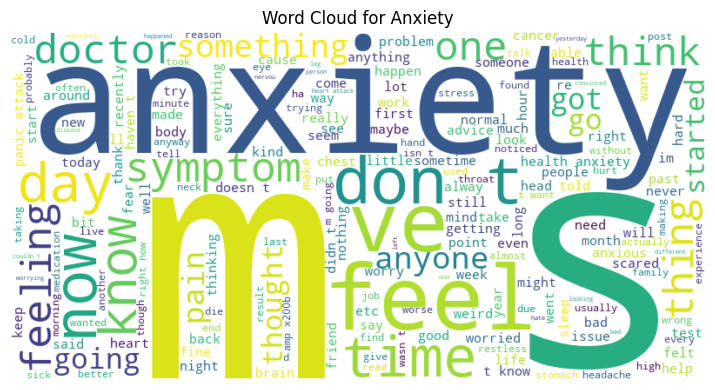

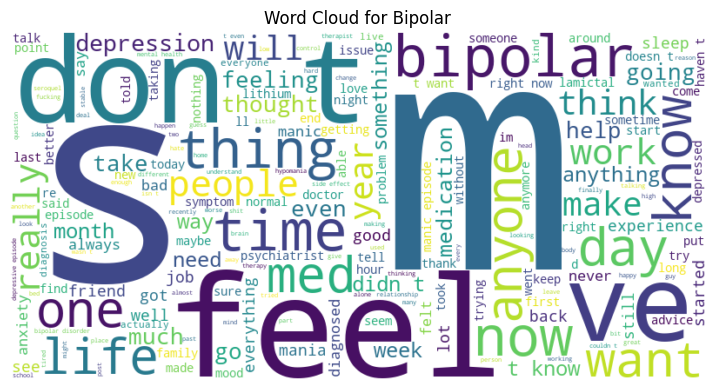

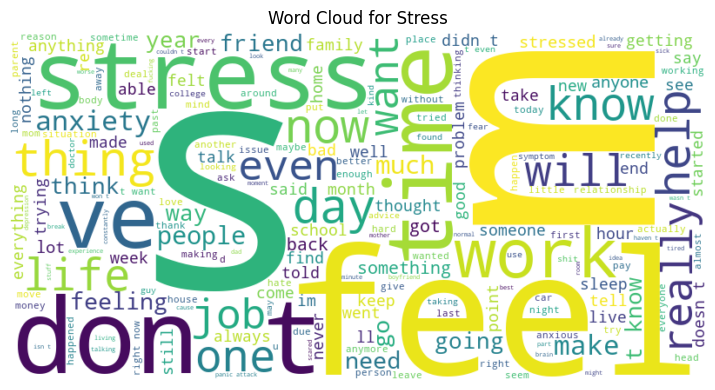

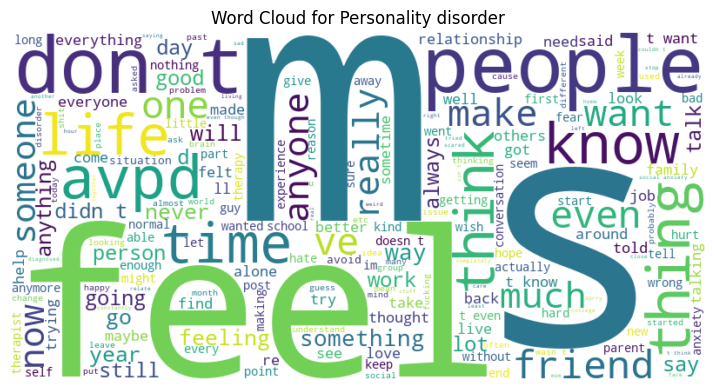

In [71]:
from wordcloud import WordCloud

WORDCLOUD_DIR = os.path.join(EDA_DIR, "Word Cloud")
os.makedirs(WORDCLOUD_DIR, exist_ok=True)

def text_for_label(df, label):
    # concatenate all texts for this label, excluding *_emo tokens
    texts = df[df[LABEL_COL] == label][TEXT_COL]
    cleaned_texts = []
    for t in texts:
        tokens = tokenize_no_emotags(t)
        cleaned_texts.append(" ".join(tokens))
    return " ".join(cleaned_texts)

labels_for_clouds = ["Normal", "Depression", "Suicidal","Anxiety", "Bipolar", "Stress", "Personality disorder"]  

for label in labels_for_clouds:
    corpus = text_for_label(df, label)
    wc = WordCloud(width=800, height=400, background_color="white").generate(corpus)

    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {label}")
    plt.tight_layout()

    plt.savefig(
        os.path.join(WORDCLOUD_DIR, f"wordcloud_{label.lower().replace(' ', '_')}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
